# Tutorial 3: Running Quantization-Aware Training (QAT) on Bert

In this tutorial, we'll build on top of Tutorial 2 by taking the Bert model fine tuned for sequence classification and running Mase's quantization pass. First, we'll run simple Post-Training Quantization (PTQ) and see how much accuracy drops. Then, we'll run some further training iterations of the quantized model (i.e. QAT) and see whether the accuracy of the trained quantized model approaches the accuracy of the original (full-precision) model.

In [6]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can create a MaseGraph for Bert by running the following cell.

In [7]:
from transformers import AutoModelForSequenceClassification

from chop import MaseGraph
import chop.passes as passes

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
INFO     Getting dummy input for prajjwal1/bert-tiny.


tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

If you have previously ran the tutorial on LoRA Finetuning, run the following cell to import the fine tuned checkpoint.

In [8]:
from pathlib import Path
from chop import MaseGraph

mg = MaseGraph.from_checkpoint(f"tutorial_2_lora")

/Users/nyalpatel/Library/CloudStorage/OneDrive-Personal/Uni/Imperial MSC/Modules/Advanced Deep Learning/Labs/mase/src/chop/ir/graph/mase_graph.py:380: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this 

## Post-Training Quantization (PTQ)

Here, we simply quantize the model and evaluate the effect in its accuracy. First, let's evaluate the model accuracy before quantization (if you're coming from Tutorial 2, this should be the same as the post-LoRA evaluation accuracy). As seen in Tutorial 2, we can use the `get_tokenized_dataset` and `get_trainer` utilities to generate a HuggingFace `Trainer` instance for training and evaluation.

In [7]:
from chop.tools import get_tokenized_dataset, get_trainer

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Map: 100%|██████████| 25000/25000 [00:03<00:00, 6923.07 examples/s]
/Users/nyalpatel/Library/CloudStorage/OneDrive-Personal/Uni/Imperial MSC/Modules/Advanced Deep Learning/Labs/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.83352


To run the quantization pass, we pass a quantization configuration dictionary as argument. This defines the quantization mode, numerical format and precision for each operator in the graph. We'll run the quantization in "by type" mode, meaning nodes are quantized according to their `mase_op`. Other modes include by name and by regex name. We'll quantize all activations, weights and biases in the model to fixed-point with the same precision. This may be sub-optimal, but works as an example. In future tutorials, we'll see how to run the `search` flow in `Mase` to find optimal quantization configurations to minimize accuracy loss.

In [8]:
import chop.passes as passes

quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

mg, _ = passes.quantize_transform_pass(
    mg,
    pass_args=quantization_config,
)

Let's evaluate the immediate effect of quantization on the model accuracy.

In [9]:
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

/Users/nyalpatel/Library/CloudStorage/OneDrive-Personal/Uni/Imperial MSC/Modules/Advanced Deep Learning/Labs/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.80704


We can save the current checkpoint for future reference (optional).

In [10]:
from pathlib import Path

mg.export(f"tutorial_3_ptq")

INFO     Exporting MaseGraph to tutorial_3_ptq.pt, tutorial_3_ptq.mz
INFO     Exporting GraphModule to tutorial_3_ptq.pt
INFO     Exporting MaseMetadata to tutorial_3_ptq.mz


### Lab 1 - Task 1a

In [23]:
import chop.passes as passes
import pandas as pd
from chop.tools import get_tokenized_dataset, get_trainer

# Load the dataset and tokenizer
dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

# Define the range of fixed-point widths to test (increments of 4)
fixed_point_widths = range(4, 33, 4)

# Store accuracy results for PTQ and QAT
results = []

best_ptq_accuracy = 0.0
best_qat_accuracy = 0.0
best_ptq_model = None
best_qat_model = None
best_ptq_width = None
best_qat_width = None


for width in fixed_point_widths:
    print(f"\nRunning quantisation with fixed-point width: {width}")

    # Update the quantization configuration dynamically
    quantization_config = {
        "by": "type",
        "default": {
            "config": {
                "name": None,
            }
        },
        "linear": {
            "config": {
                "name": "integer",
                # data precision
                "data_in_width": width,
                "data_in_frac_width": width // 2,  # Half of the bits for fractional part
                # weight precision
                "weight_width": width,
                "weight_frac_width": width // 2,
                # bias precision
                "bias_width": width,
                "bias_frac_width": width // 2,
            }
        },
    }

    # Apply PTQ (Post-Training Quantization)
    mg_ptq, _ = passes.quantize_transform_pass(
        mg,
        pass_args=quantization_config,
    )

    # Evaluate PTQ accuracy
    trainer_ptq = get_trainer(
        model=mg_ptq.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        use_mps_device=True
    )

    eval_results_ptq = trainer_ptq.evaluate()
    ptq_accuracy = eval_results_ptq["eval_accuracy"]
    print(f"Fixed-point width {width} (PTQ): Accuracy = {ptq_accuracy:.4f}")

     # Track best PTQ model
    if ptq_accuracy > best_ptq_accuracy:
        best_ptq_accuracy = ptq_accuracy
        best_ptq_model = mg_ptq
        best_ptq_width = width

    # Perform QAT (Quantization-Aware Training)
    trainer_qat = get_trainer(
        model=mg_ptq.model,  # Start with the PTQ model for fine-tuning
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        use_mps_device=True
    )

    trainer_qat.train()
    eval_results_qat = trainer_qat.evaluate()
    qat_accuracy = eval_results_qat["eval_accuracy"]
    print(f"Fixed-point width {width} (QAT): Accuracy = {qat_accuracy:.4f}")

    # Track best QAT model
    if qat_accuracy > best_qat_accuracy:
        best_qat_accuracy = qat_accuracy
        best_qat_model = mg_ptq
        best_qat_width = width

    # Store results
    results.append({
        "Fixed_Point_Width": width,
        "PTQ_Accuracy": ptq_accuracy,
        "QAT_Accuracy": qat_accuracy
    })

    print(results)


# Save results to CSV
df_results = pd.DataFrame(results)
df_results.to_csv("Lab1 - T1 - Results.csv", index=False)

print("Results saved to 'Lab1 - T1 - Results.csv'")

# Export the best PTQ and QAT models
if best_ptq_model:
    best_ptq_model.export(f"tutorial_3_qat-precision-{best_ptq_width}")
    print(f"Best PTQ model exported: tutorial_3_qat-precision-{best_ptq_width}")

if best_qat_model:
    best_qat_model.export(f"tutorial_3_qat-precision-{best_qat_width}")
    print(f"Best QAT model exported: tutorial_3_qat-precision-{best_qat_width}")



INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.



Running quantisation with fixed-point width: 4


/Users/nyalpatel/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/training_args.py:2243: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(
/Users/nyalpatel/Library/CloudStorage/OneDrive-Personal/Uni/Imperial MSC/Modules/Advanced Deep Learning/Labs/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Fixed-point width 4 (PTQ): Accuracy = 0.5000


/Users/nyalpatel/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/training_args.py:2243: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(
/Users/nyalpatel/Library/CloudStorage/OneDrive-Personal/Uni/Imperial MSC/Modules/Advanced Deep Learning/Labs/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Fixed-point width 32 (PTQ): Accuracy = 0.8348


/Users/nyalpatel/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/training_args.py:2243: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(
/Users/nyalpatel/Library/CloudStorage/OneDrive-Personal/Uni/Imperial MSC/Modules/Advanced Deep Learning/Labs/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.401700
1000,0.387300
1500,0.398500
2000,0.375300
2500,0.384400
3000,0.386800


INFO     Exporting MaseGraph to tutorial_3_qat-precision-32.pt, tutorial_3_qat-precision-32.mz
INFO     Exporting GraphModule to tutorial_3_qat-precision-32.pt
INFO     Exporting MaseMetadata to tutorial_3_qat-precision-32.mz
INFO     Exporting MaseGraph to tutorial_3_qat-precision-16.pt, tutorial_3_qat-precision-16.mz
INFO     Exporting GraphModule to tutorial_3_qat-precision-16.pt
INFO     Exporting MaseMetadata to tutorial_3_qat-precision-16.mz


Fixed-point width 32 (QAT): Accuracy = 0.8407
[{'Fixed_Point_Width': 4, 'PTQ_Accuracy': 0.5, 'QAT_Accuracy': 0.5}, {'Fixed_Point_Width': 8, 'PTQ_Accuracy': 0.807, 'QAT_Accuracy': 0.8386}, {'Fixed_Point_Width': 12, 'PTQ_Accuracy': 0.82776, 'QAT_Accuracy': 0.84036}, {'Fixed_Point_Width': 16, 'PTQ_Accuracy': 0.8338, 'QAT_Accuracy': 0.84096}, {'Fixed_Point_Width': 20, 'PTQ_Accuracy': 0.83432, 'QAT_Accuracy': 0.84064}, {'Fixed_Point_Width': 24, 'PTQ_Accuracy': 0.83452, 'QAT_Accuracy': 0.84068}, {'Fixed_Point_Width': 28, 'PTQ_Accuracy': 0.83468, 'QAT_Accuracy': 0.84068}, {'Fixed_Point_Width': 32, 'PTQ_Accuracy': 0.83476, 'QAT_Accuracy': 0.84068}]
Results saved to 'Lab1 - T1 - Results.csv'
Best PTQ model exported: tutorial_3_qat-precision-32
Best QAT model exported: tutorial_3_qat-precision-16


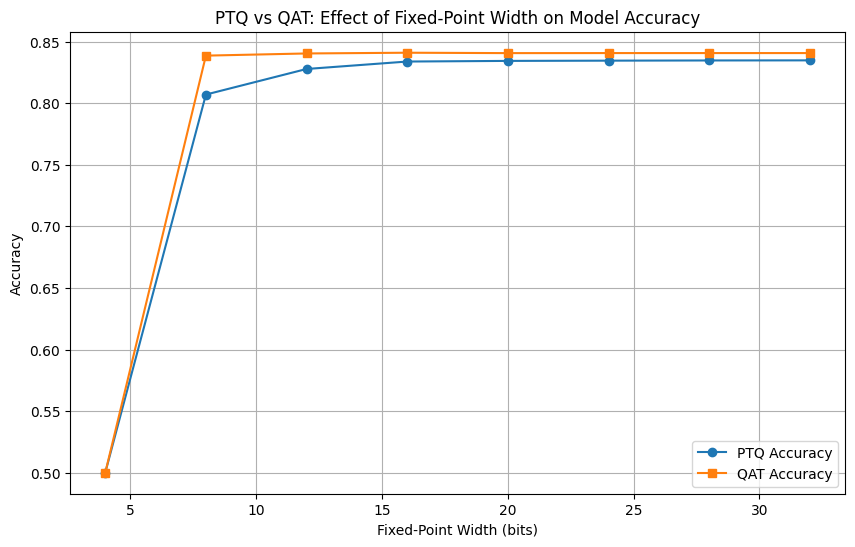

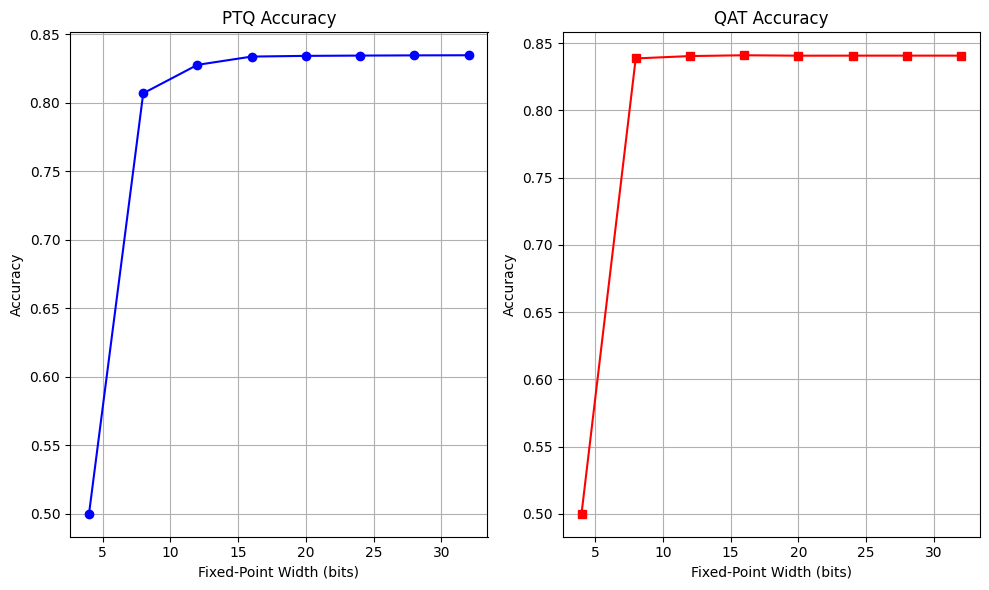

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the results from CSV
df_results = pd.read_csv("Lab1 - T1 - Results.csv")

# Plot PTQ vs QAT accuracy comparison
plt.figure(figsize=(10, 6))
plt.plot(df_results["Fixed_Point_Width"], df_results["PTQ_Accuracy"], marker="o", linestyle="-", label="PTQ Accuracy")
plt.plot(df_results["Fixed_Point_Width"], df_results["QAT_Accuracy"], marker="s", linestyle="-", label="QAT Accuracy")
plt.xlabel("Fixed-Point Width (bits)")
plt.ylabel("Accuracy")
plt.title("PTQ vs QAT: Effect of Fixed-Point Width on Model Accuracy")
plt.legend()
plt.grid()
plt.savefig("Lab1 - T1 - PTQ vs QAT Accuracy.png")
plt.show()

# Plot separate curves for PTQ and QAT
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.plot(df_results["Fixed_Point_Width"], df_results["PTQ_Accuracy"], marker="o", linestyle="-", color="blue")
plt.xlabel("Fixed-Point Width (bits)")
plt.ylabel("Accuracy")
plt.title("PTQ Accuracy")
plt.grid()
plt.savefig("Lab1 - T1 - PTQ Accuracy.png")

plt.subplot(1, 2, 2)
plt.plot(df_results["Fixed_Point_Width"], df_results["QAT_Accuracy"], marker="s", linestyle="-", color="red")
plt.xlabel("Fixed-Point Width (bits)")
plt.ylabel("Accuracy")
plt.title("QAT Accuracy")
plt.grid()
plt.savefig("Lab1 - T1 - QAT Accuracy.png")

plt.tight_layout()
plt.show()


## Quantization-Aware Training (QAT)

You should have seen in the last section that quantization can lead to a significant drop in accuracy. Next, we'll run QAT to evaluate whether this performance gap can be reduced. To run QAT in Mase, all you need to do is include the model back in your training loop after running the quantization pass.

In [11]:
# Evaluate accuracy
trainer.train()
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

Step,Training Loss
500,0.413300
1000,0.402200
1500,0.406700
2000,0.388600
2500,0.389900
3000,0.395800


Evaluation accuracy: 0.8382


We can see the accuracy of the quantized model can match (or sometimes exceed) the full precision model, with a much lower memory requirement to store the weights. Finally, save the final checkpoint for future tutorials.

In [12]:
from pathlib import Path

mg.export(f"tutorial_3_qat")

INFO     Exporting MaseGraph to tutorial_3_qat.pt, tutorial_3_qat.mz
INFO     Exporting GraphModule to tutorial_3_qat.pt
INFO     Exporting MaseMetadata to tutorial_3_qat.mz
